In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

## 1. Import data.
Make sure all the files are in the working directory.

In [8]:
csv_paths = list(Path("../Dataset/data_new_approach/").glob("*.csv"))

print("CSV files found:")
for p in csv_paths:
    print(p.name)

CSV files found:
marcus_by_goldman_sachs__combined_us.csv
chase__combined_us.csv
bank_of_america__combined_us.csv
wells_fargo__combined_us.csv
citi__combined_us.csv


In [9]:
# import files
raw = pd.concat(
    [
        pd.read_csv(p, dtype=str).assign(source_file=p.name)
        for p in csv_paths
    ],
    ignore_index=True
)

## 2. Data Overview

In [10]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5450 entries, 0 to 5449
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   platform       5450 non-null   object
 1   storefront     5450 non-null   object
 2   app_id         2450 non-null   object
 3   review_id      5450 non-null   object
 4   date           5450 non-null   object
 5   user           5450 non-null   object
 6   rating         5450 non-null   object
 7   title          2450 non-null   object
 8   review         5450 non-null   object
 9   version        2450 non-null   object
 10  package        3000 non-null   object
 11  thumbsUpCount  3000 non-null   object
 12  appVersion     2774 non-null   object
 13  source_file    5450 non-null   object
dtypes: object(14)
memory usage: 596.2+ KB


In [11]:
raw.describe(include = "all")

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
count,5450,5450,2450,5450,5450,5450,5450,2450,5450,2450,3000,3000,2774,5450
unique,2,1,5,5450,5450,5400,5,2064,4960,61,5,24,108,5
top,google_play,us,1489511701.0,13976661175,2026-04-19T18:13:04-07:00,A Google user,5,Great,good,4.732,com.marcus.android,0.0,9.93.1,marcus_by_goldman_sachs__combined_us.csv
freq,3000,5450,490,1,1,18,3256,24,54,230,600,2670,479,1090


In [12]:
raw.head()

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
0,app_store,us,1489511701.0,13976661175,2026-04-19T18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv
1,app_store,us,1489511701.0,13968552342,2026-04-17T13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv
2,app_store,us,1489511701.0,13967597795,2026-04-17T07:34:37-07:00,Pichu4ever,5,Pato,Great,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv
3,app_store,us,1489511701.0,13965458699,2026-04-16T16:11:11-07:00,Ann22k,5,Saving or CD,Easy to navigate and transfers back to account...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv
4,app_store,us,1489511701.0,13963956841,2026-04-16T06:48:48-07:00,binbincheong,5,Easy peasy,Very easy to use and efficient! Good interest...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv


In [13]:
platform_counts = (
    raw
    .groupby("platform")
    .size()
    .reset_index(name="n_reviews")
)

platform_counts

,platform,n_reviews
0,app_store,2450
1,google_play,3000


In [14]:
missing_raw = (
    raw
    .isna()
    .sum()
    .reset_index()
)

missing_raw.columns = ["variable", "n_missing"]

missing_raw = (
    missing_raw
    .sort_values("n_missing", ascending=False)
    .reset_index(drop=True)
)

missing_raw

,variable,n_missing
0,app_id,3000
1,title,3000
2,version,3000
3,appVersion,2676
4,package,2450
5,thumbsUpCount,2450
6,platform,0
7,storefront,0
8,review_id,0
9,date,0


In [15]:
missing_by_platform = (
    raw
    .groupby("platform")
    .agg(lambda col: col.isna().sum())
    .reset_index()
)

missing_by_platform

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
0,app_store,0,0,0,0,0,0,0,0,0,2450,2450,2450,0
1,google_play,0,3000,0,0,0,0,3000,0,3000,0,0,226,0


In [16]:
raw["raw_text"] = (
    raw["title"].fillna("") + " " + raw["review"].fillna("")
)

raw["raw_length_words"] = (
    raw["raw_text"]
    .str.count(r"\S+")
)

In [17]:
raw["raw_length_words"].describe()

count    5450.000000
mean       22.044587
std        29.047547
min         1.000000
25%         4.000000
50%        11.000000
75%        28.000000
max       377.000000
Name: raw_length_words, dtype: float64

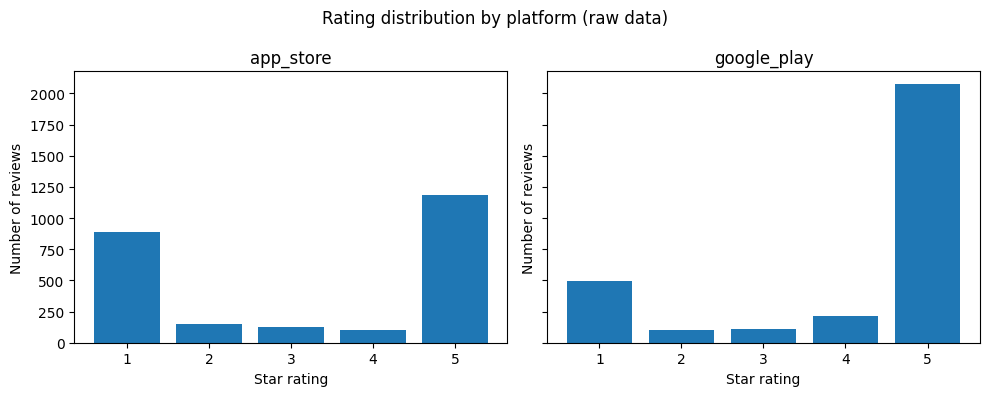

In [18]:
# Count the ratings by platform
rating_counts = (
    raw
    .groupby(["platform", "rating"])
    .size()
    .reset_index(name="n_reviews")
)

# Create one bar chart per platform
platforms = rating_counts["platform"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(platforms),
    figsize=(10, 4),
    sharey=True
)

# If there is only one platform, make axes iterable
if len(platforms) == 1:
    axes = [axes]

for ax, platform in zip(axes, platforms):
    data = rating_counts[rating_counts["platform"] == platform]

    ax.bar(data["rating"], data["n_reviews"])
    ax.set_title(platform)
    ax.set_xlabel("Star rating")
    ax.set_ylabel("Number of reviews")

fig.suptitle("Rating distribution by platform (raw data)")
plt.tight_layout()
plt.show()

In [ ]:
# word count distribution
raw['review_length'] = raw['review'].str.len()
raw['word_count'] = raw['review'].str.split().str.len()
raw[['review_length', 'word_count']].describe()

,review_length,word_count
count,5450.000000,5450.000000
mean,110.974495,20.642385
std,153.160241,28.176683
min,1.000000,1.000000
25%,19.000000,4.000000
50%,55.000000,10.000000
75%,140.000000,26.000000
max,2079.000000,371.000000


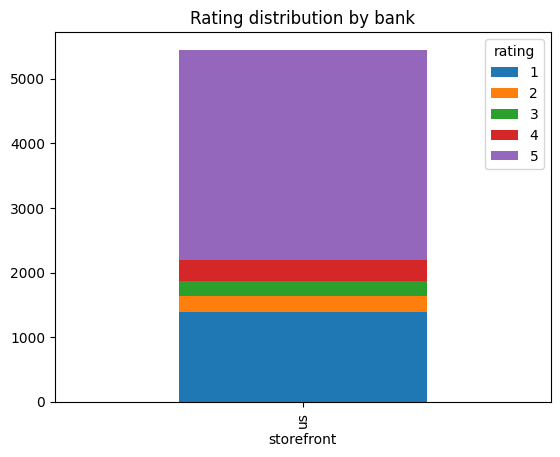

In [20]:
raw.groupby('storefront')['rating'].value_counts().unstack().plot(kind='bar', stacked=True)
plt.title("Rating distribution by bank")
plt.show()

In [23]:
raw['sentiment_group'] = raw['rating'].apply(lambda x: 'positive' if int(x) >= 4 else 'negative')
raw.groupby('sentiment_group')['word_count'].mean()

sentiment_group
negative    37.289067
positive    11.911608
Name: word_count, dtype: float64